In [ ]:
import numpy as np
import netCDF4 as nc
import numba
import pandas as pd
import geospatialtools.gdal_tools as gdal_tools
import gdal_tools
import sys
import matplotlib.pyplot as plt
import rasterio
import os
import matplotlib.colors as colors

# OUTPUT PATH

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.system("mkdir -p {}".format(outputdir))

# FULL 1600-CID PATH

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"

print("Simulation path:", path, flush=True)

# SETTINGS

buffer = 0

cid_list = range(1, 1601)

var2plot = ["dem", "slope", "y_aspect", "x_aspect"]

# READ HRU AND CID MAPS

hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")
metad = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")

print(metad, flush=True)

coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])

coords_x = coord_xx0[buffer:np.size(coord_xx0)-buffer+1]
coords_y = coord_yy0[buffer:np.size(coord_yy0)-buffer+1]

#  PLACE DATA FUNCTION 

# @numba.jit()
def place_data(tmp, model, hrus, cids, val):
    for i in range(tmp.shape[0]):
        for j in range(tmp.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])
            if (hru != -9999) & (ucid == val):
                tmp[i, j] = model[hru]
    return tmp

# PLOT 2x2 FIGURE

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for j, ax in enumerate(axes):

    var = var2plot[j]

    print("\nPlotting", var, flush=True)

    tmp = np.copy(hrus)
    tmp[:] = -9999.0

    for c in cid_list:

        if c % 50 == 0:
            print(" Processing CID", c, flush=True)

        fp_path = path + "%s/input_file.nc" % c

        if not os.path.exists(fp_path):
            print("Missing:", fp_path, flush=True)
            continue

        fp = nc.Dataset(fp_path)

        if var in ["lwdown", "swdown"]:
            grp = fp.groups["meteorology"]
        else:
            grp = fp.groups["parameters"]

        if var not in grp.variables:
            print(var, "missing in CID", c, flush=True)
            fp.close()
            continue

        data = np.array(grp.variables[var][:])

        tmp = place_data(tmp, data, hrus, cids, int(c))

        fp.close()

    final_map = np.ma.masked_array(tmp, tmp == -9999)
    final_map[final_map == -9999] = np.nan

    map_shape = final_map.shape

    final_map = final_map[
        buffer:map_shape[0]-buffer+1,
        buffer:map_shape[1]-buffer+1
    ]

    im = ax.pcolormesh(
        coords_x,
        coords_y,
        np.flipud(final_map),
        cmap="terrain",
        shading="auto"
    )

    ax.set_title(var)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    fig.colorbar(
        im,
        ax=ax,
        shrink=0.98,
        fraction=0.046,
        pad=0.04
    )

plt.tight_layout()

outfile = os.path.join(
    outputdir,
    "static_variables_1600cid_dem_slope_aspect_2x2_new_plot.png"
)

plt.savefig(outfile, dpi=300, bbox_inches="tight")

print("Saved:", outfile, flush=True)

plt.show()
plt.close(fig)

Plotting dem
  CID 50
  CID 100
  CID 150
  CID 200
  CID 250
  CID 300
  CID 350
  CID 400
  CID 450
  CID 500
  CID 550
  CID 600
  CID 650
  CID 700
  CID 750
  CID 800
  CID 850
  CID 900
  CID 950
  CID 1000
  CID 1050
  CID 1100
  CID 1150
  CID 1200
  CID 1250
  CID 1300
  CID 1350
  CID 1400
  CID 1450
  CID 1500
  CID 1550
  CID 1600
Plotting slope
  CID 50
  CID 100
  CID 150
  CID 200
  CID 250
  CID 300
  CID 350
  CID 400
  CID 450
  CID 500
  CID 550
  CID 600
  CID 650
  CID 700
  CID 750
  CID 800
  CID 850
  CID 900
  CID 950
  CID 1000
  CID 1050
  CID 1100
  CID 1150
  CID 1200
  CID 1250
  CID 1300
  CID 1350
  CID 1400
  CID 1450
  CID 1500
  CID 1550
  CID 1600
Plotting y_aspect
  CID 50
  CID 100
  CID 150
  CID 200
  CID 250
  CID 300
  CID 350
  CID 400
  CID 450
  CID 500
  CID 550
  CID 600
  CID 650
  CID 700
  CID 750
  CID 800
  CID 850
  CID 900
  CID 950
  CID 1000
  CID 1050
  CID 1100
  CID 1150
  CID 1200
  CID 1250
  CID 1300
  CID 1350
  CID 1400
  

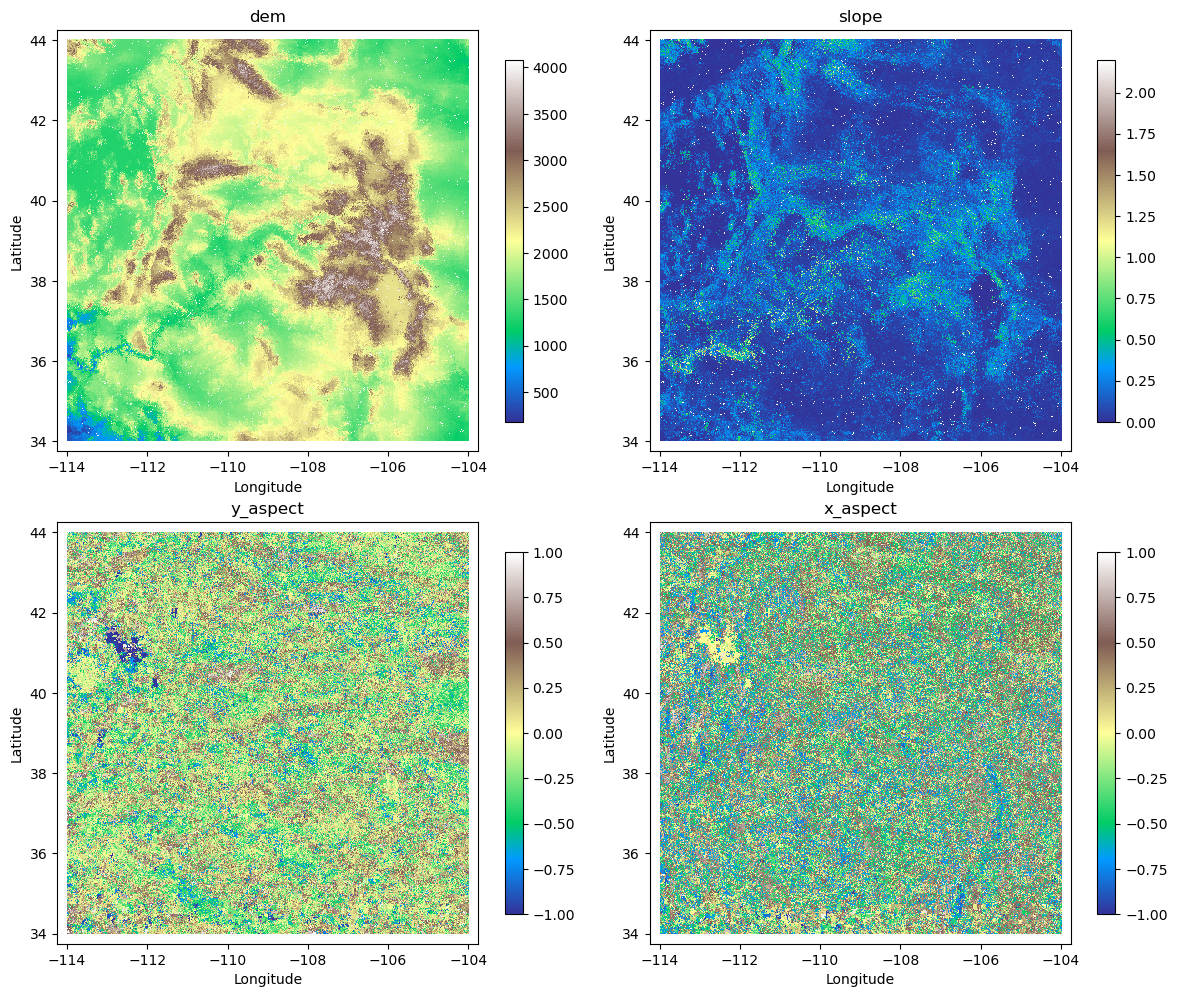

In [1]:
import os
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"

hrus_file = path + "postprocess/hrus.vrt"
cids_file = path + "postprocess/cids.vrt"

hrus = gdal_tools.read_raster(hrus_file)
cids = gdal_tools.read_raster(cids_file)
metad = gdal_tools.retrieve_metadata(hrus_file)

extent = [metad["minx"], metad["maxx"], metad["miny"], metad["maxy"]]

var2plot = ["dem", "slope", "y_aspect", "x_aspect"]

cid_list = range(1, 1601)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for j, ax in enumerate(axes):

    var = var2plot[j]
    print(f"Plotting {var}", flush=True)

    final_map = np.full(hrus.shape, -9999.0, dtype=np.float32)

    for c in cid_list:

        if c % 50 == 0:
            print(f"  CID {c}", flush=True)

        fp_path = path + f"{c}/input_file.nc"

        if not os.path.exists(fp_path):
            continue

        with nc.Dataset(fp_path) as fp:
            grp = fp.groups["parameters"]
            data = np.array(grp.variables[var][:], dtype=np.float32)

        mask = (hrus != -9999) & (cids == c)

        hru_ids = hrus[mask].astype(np.int32)

        # HRU 
        hru_index = hru_ids - 1

        valid = (hru_index >= 0) & (hru_index < len(data))

        rows, cols = np.where(mask)
        final_map[rows[valid], cols[valid]] = data[hru_index[valid]]

    final_map[final_map == -9999.0] = np.nan

    im = ax.imshow(
        final_map,
        origin="upper",
        extent=extent,
        cmap="terrain",
        interpolation="nearest"
    )

    ax.set_title(var)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    plt.colorbar(im, ax=ax, shrink=0.85)

plt.tight_layout()

outfile = os.path.join(outputdir, "static_dem_slope_aspect_100hru_full_domain.png")
plt.savefig(outfile, dpi=300, bbox_inches="tight")

print("Saved:", outfile)
plt.show()

In [1]:
import os
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

# PATHS

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"

print("Simulation path:", path, flush=True)

# READ FULL-DOMAIN HRU AND CID MAPS

hrus_file = path + "postprocess/hrus.vrt"
cids_file = path + "postprocess/cids.vrt"

hrus = gdal_tools.read_raster(hrus_file).astype(np.int32)
cids = gdal_tools.read_raster(cids_file).astype(np.int32)

metad = gdal_tools.retrieve_metadata(hrus_file)
extent = [metad["minx"], metad["maxx"], metad["miny"], metad["maxy"]]

print("HRU min:", np.nanmin(hrus[hrus != -9999]))
print("HRU max:", np.nanmax(hrus[hrus != -9999]))

# VARIABLES

var2plot = ["dem", "slope", "y_aspect", "x_aspect"]

cid_list = range(1, 1601)

# PLOT

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for j, ax in enumerate(axes):

    var = var2plot[j]
    print(f"\nPlotting {var}", flush=True)

    final_map = np.full(hrus.shape, -9999.0, dtype=np.float32)

    for cid in cid_list:

        if cid % 50 == 0:
            print(f"  Processing CID {cid}", flush=True)

        fp_path = path + f"{cid}/input_file.nc"

        if not os.path.exists(fp_path):
            print(f"Missing: {fp_path}", flush=True)
            continue

        with nc.Dataset(fp_path) as fp:

            grp = fp.groups["parameters"]

            if var not in grp.variables:
                print(f"{var} missing in CID {cid}", flush=True)
                continue

            data = np.array(grp.variables[var][:], dtype=np.float32)

        mask = (hrus != -9999) & (cids == cid)

        if not np.any(mask):
            continue

        rows, cols = np.where(mask)

        hru_ids = hrus[mask].astype(np.int32)

        # HRU IDs are 0-based: 0 to 99
        valid = (hru_ids >= 0) & (hru_ids < len(data))

        final_map[rows[valid], cols[valid]] = data[hru_ids[valid]]

    final_map[final_map == -9999.0] = np.nan

    print(
        var,
        "valid pixels:", np.sum(np.isfinite(final_map)),
        "min:", np.nanmin(final_map),
        "max:", np.nanmax(final_map),
        flush=True
    )

    im = ax.imshow(
        final_map,
        origin="upper",
        extent=extent,
        cmap="terrain",
        interpolation="nearest"
    )

    ax.set_title(var)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    plt.colorbar(im, ax=ax, shrink=0.85)

plt.tight_layout()

outfile = os.path.join(
    outputdir,
    "static_dem_slope_aspect_100hru_full_domain_0based.png"
)

plt.savefig(outfile, dpi=300, bbox_inches="tight")

print("Saved:", outfile, flush=True)

plt.show()

Simulation path: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/
HRU min: 0
HRU max: 99

Plotting dem
  Processing CID 50
  Processing CID 100
  Processing CID 150
  Processing CID 200
  Processing CID 250
  Processing CID 300
  Processing CID 350
  Processing CID 400
  Processing CID 450
  Processing CID 500
  Processing CID 550
  Processing CID 600
  Processing CID 650
  Processing CID 700
  Processing CID 750
  Processing CID 800
